In [1]:
using CSV
using DataFrames
using DelimitedFiles
using CairoMakie
using LsqFit

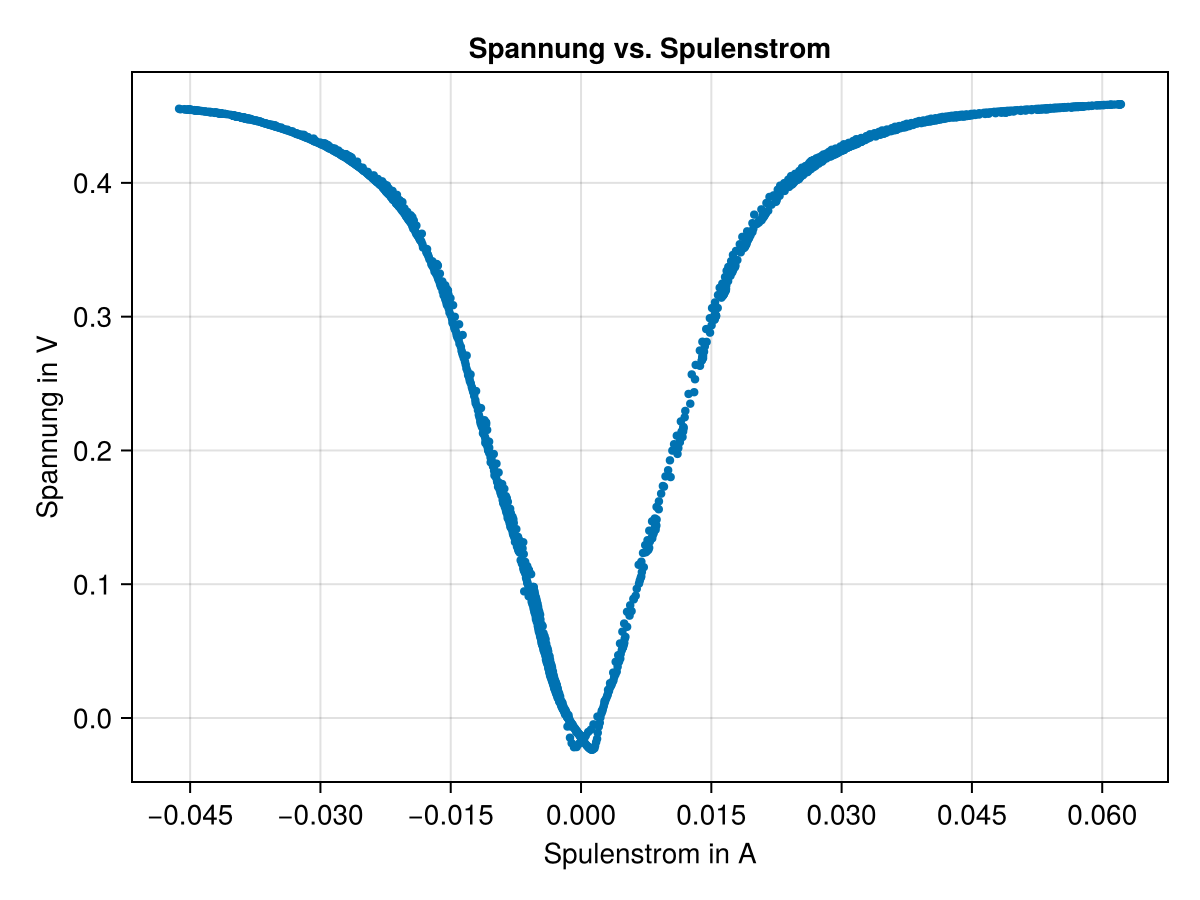

In [2]:
messung = readdlm("Hspule_sensor2_2", Float64, skipstart=2)
U22 = messung[:,2]
I22 = messung[:,1]

fig = Figure()
ax = Axis(fig[1,1], xlabel = "Spulenstrom in A", ylabel = "Spannung in V", title = "Spannung vs. Spulenstrom",
xticks = LinearTicks(8))
scatter!(ax, I22, U22, markersize = 6)
fig

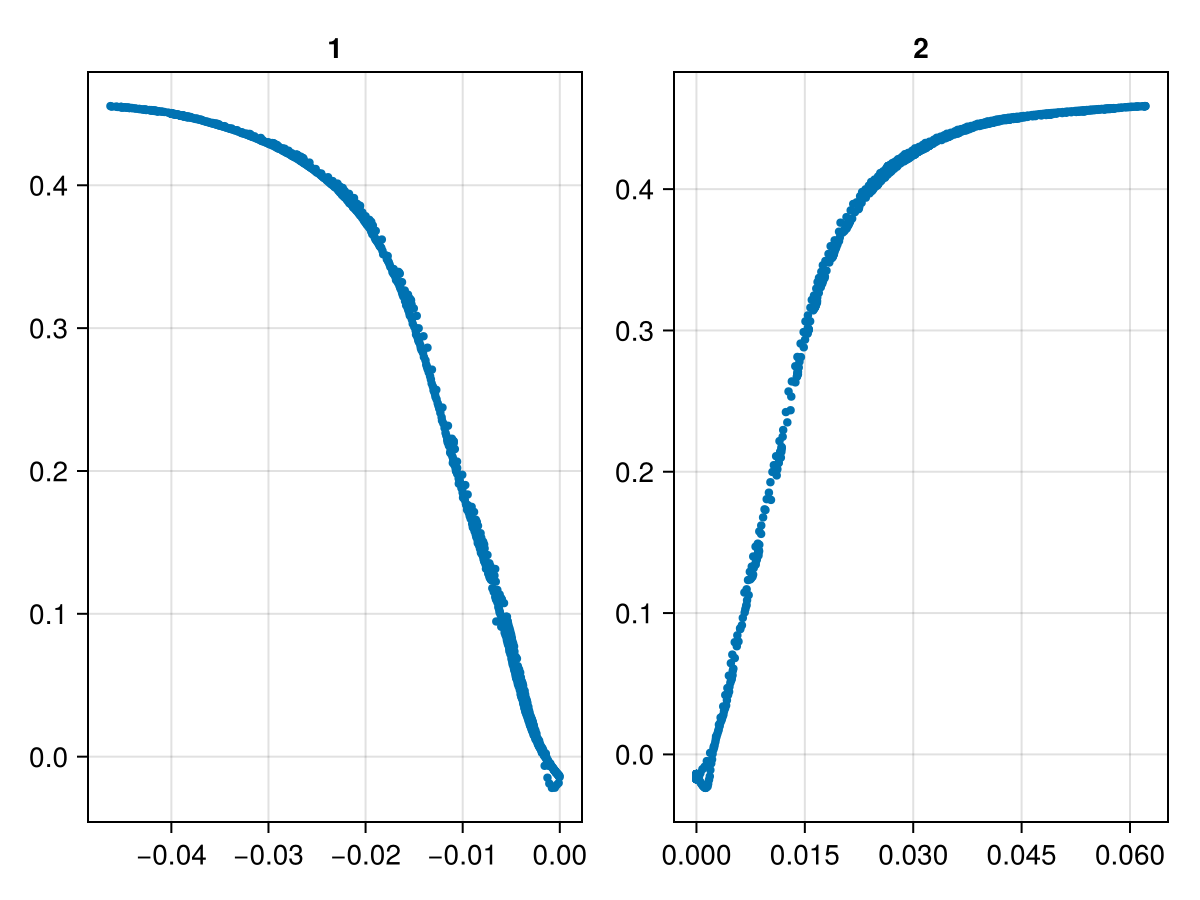

In [3]:
#Kurve in zwei Teilen , unterscheide von pos und neg
mask_neg = I22 .< 0.0
mask_pos = I22 .>= 0.0

#Teil 1 Links 
U22_1 = U22[mask_neg]
I22_1 = I22[mask_neg]

#Teil 2 rechts
U22_2 = U22[mask_pos]
I22_2 = I22[mask_pos]

fig2 = Figure()
ax1 = Axis(fig2[1,1], xticks = LinearTicks(6), title="1")
ax2 = Axis(fig2[1,2], xticks = LinearTicks(6),title="2")

scatter!(ax1, I22_1, U22_1, markersize = 6)
scatter!(ax2, I22_2, U22_2, markersize=6)
fig2

In [21]:
mask_1 = (I22_1 .>= -0.016) .& (I22_1 .<= -0.005)
mask_2 = (I22_2 .>= 0.005) .& (I22_2 .< 0.016)

x_fit_1 = I22_1[mask_1]
y_fit_1 = U22_1[mask_1]

x_fit_2 = I22_2[mask_2]
y_fit_2 = U22_2[mask_2];

Steigung m = -22.465226604958374 ± 0.12001382029745795
y-Abschnitt b =-0.03448239489009411 ± 0.001225233939718696


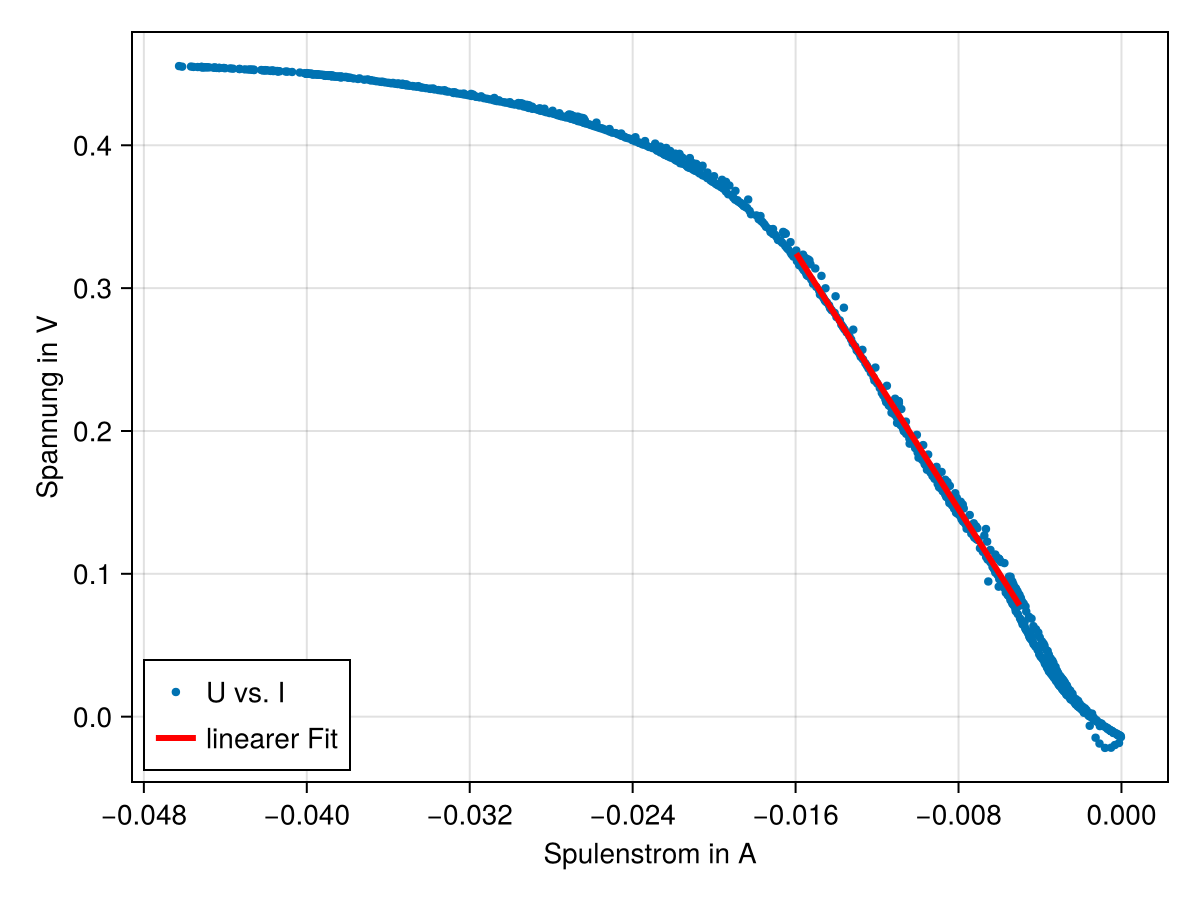

In [19]:
#fit1  durchführen 
@. gerade(x, p) = p[1]*x + p[2]
p0 = [-0.022, 0.004]
fit = curve_fit(gerade, x_fit_1, y_fit_1, p0)

#m und b geben lassen
m, b = fit.param
Δm, Δb = stderror(fit)

println("Steigung m = $m ± $Δm")
println("y-Abschnitt b =$b ± $Δb")

fig3= Figure()
ax = Axis(fig3[1,1], title = "" ,xlabel = "Spulenstrom in A", ylabel = "Spannung in V",
xticks = LinearTicks(8))
scatter!(ax, I22_1, U22_1, label = "U vs. I", markersize = 6)


I22_1_fit = range(minimum(x_fit_1 ), maximum(x_fit_1), length = 100)
U22_1_fit = gerade(I22_1_fit, fit.param)

lines!(ax, I22_1_fit, U22_1_fit, label = "linearer Fit", color = :red, linewidth = 3)

axislegend(ax, position = :lb)

fig3




Steigung m = 22.976952773572396 ± 0.1707015537451983
y-Abschnitt b =-0.04965385152483585 ± 0.0018651506099611613


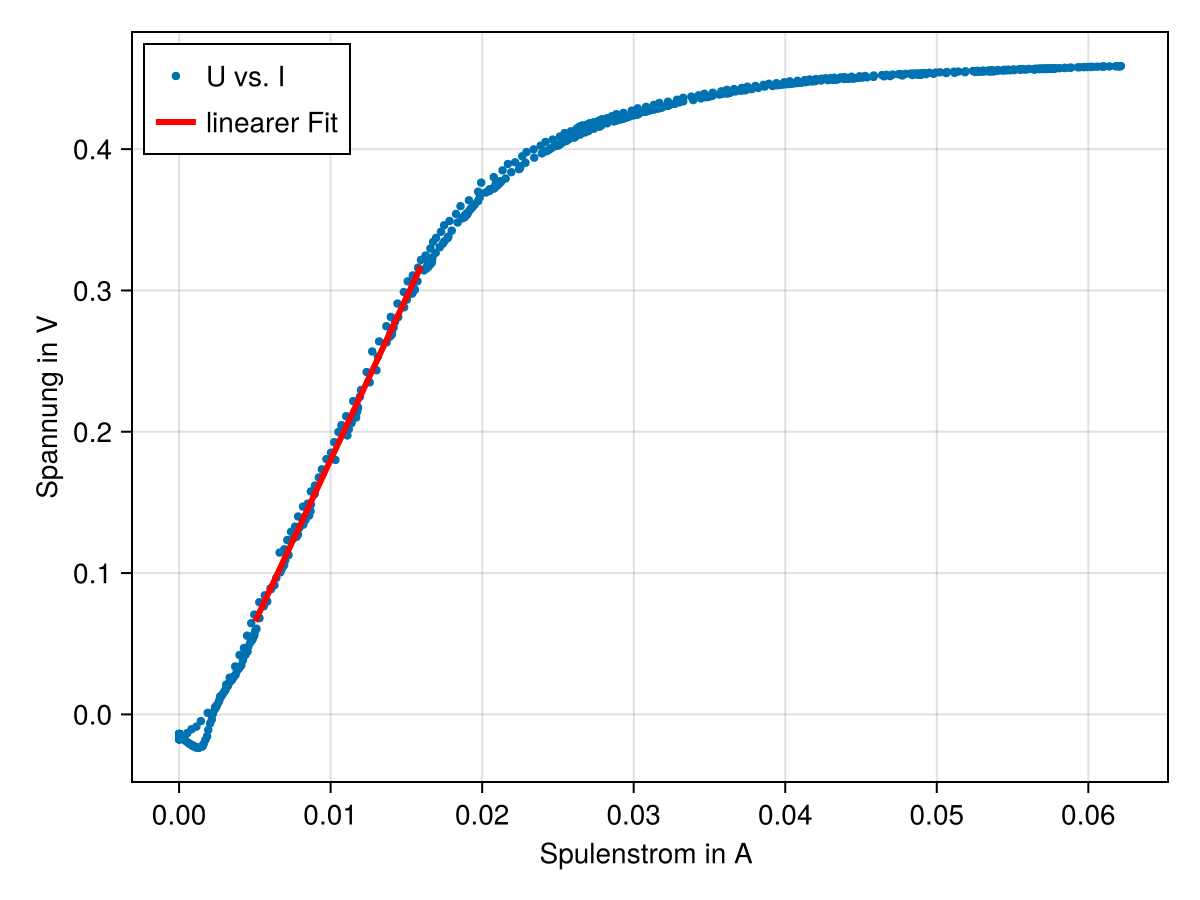

In [22]:
#fit2
@. gerade(x, p) = p[1]*x + p[2]
p0 = [20, 0.0]
fit = curve_fit(gerade, x_fit_2, y_fit_2, p0)

#m und b geben lassen
m, b = fit.param
Δm, Δb = stderror(fit)

println("Steigung m = $m ± $Δm")
println("y-Abschnitt b =$b ± $Δb")

fig4= Figure()
ax = Axis(fig4[1,1], title = "" ,xlabel = "Spulenstrom in A ", ylabel = "Spannung in V",
xticks = LinearTicks(8))


scatter!(ax, I22_2, U22_2, label = "U vs. I", markersize = 6)


I22_2_fit = range(minimum(x_fit_2 ), maximum(x_fit_2), length = 100)
U22_2_fit = gerade(I22_2_fit, fit.param)

lines!(ax, I22_2_fit, U22_2_fit, label = "linearer Fit", color = :red, linewidth = 3)

axislegend(ax, position = :lt)

fig4



In [23]:
save("Spannung_vs_Strom_2.pdf", fig)
save("Fit_links_2.pdf", fig3)
save("Fit_rechts_2.pdf", fig4)

CairoMakie.Screen{PDF}


In [ ]:
μ0 = 4π*1e-7
r = 0.065 #in m 
S = 3282 #in V/T 
ΔS =  20.55#in v/T 
m1 = 22.465 #in V/A 
Δm1 = 0.12
m2 = 22.977
Δm2 = 0.17
c = (4/5)^(3/2)

m = (m1+m2)/2
Δm = √( (Δm1/2)^2 + (Δm2/2)^2 )
N = (m*r) / (μ0*c*S)
ΔN = r/(μ0*c*S) *√( (Δm)^2 + (ΔS*m/S)^2  )


println("Steigung m = $(round(m, digits=3)) ± $(round(Δm, digits=3))")
println("Windungszahl N =$(round(Int,N)) ± $(round(Int,ΔN))")

Steigung m = 22.721 ± 0.104
Windungszahl N =500 ± 4
